# Multiclass Classification of Wildfire Intensity from NASA FIRMS Data

**Nama:** Dhea Yuza Fadiya  
**Dataset:** NASA FIRMS Multi-Sensor Global Wildfire Detections (April 21–25, 2026)  
**Sumber:** [Kaggle](https://www.kaggle.com/datasets/sarcasmos/nasa-firms-multi-sensor-global-wildfire-detections)  

---

## 📌 Deskripsi Proyek

NASA melalui sistem **FIRMS (Fire Information for Resource Management System)** menyediakan data deteksi kebakaran berbasis satelit dari sensor VIIRS (NOAA-21, NOAA-20, Suomi-NPP) dan MODIS (Terra & Aqua). Dataset ini berisi **562,227 deteksi** kebakaran aktif secara global dalam periode 5 hari (21–25 April 2026).

Proyek ini membangun model **klasifikasi multiclass** untuk memprediksi **intensitas kebakaran** berdasarkan fitur fisik deteksi satelit.

### 🔥 Definisi Wildfire Intensity

Intensitas kebakaran mengacu pada kekuatan energi api yang diukur secara fisik oleh sensor satelit:

| Fitur Utama | Deskripsi |
|---|---|
| **Fire Radiative Power (FRP)** | Energi radiasi yang dipancarkan api (MW) |
| **Brightness Temperature** | Suhu kecerahan inframerah yang dideteksi satelit (Kelvin) |

### 🎯 Target Klasifikasi (4 Kelas)

| Kelas | Label | Rentang FRP |
|---|---|---|
| 0 | Low | FRP < 10 MW |
| 1 | Moderate | 10 ≤ FRP < 50 MW |
| 2 | High | 50 ≤ FRP < 200 MW |
| 3 | Extreme | FRP ≥ 200 MW |

> Threshold dipilih berdasarkan karakteristik distribusi FRP dataset ini dan merujuk pada rentang yang umum digunakan dalam fire remote sensing literature (FRP < 10 MW = deteksi di batas sensitivitas sensor, FRP ≥ 200 MW = kejadian ekstrem yang kurang dari 2% total deteksi). Nilai FRP < 10 MW berada di atau di bawah batas deteksi minimum sensor MODIS (~5–8 MW per piksel), sehingga kelas Low merepresentasikan deteksi di ambang batas sensitivitas sensor (Sperling et al., 2020). Threshold 50 MW dan 200 MW ditentukan berdasarkan distribusi aktual FRP pada dataset ini.

# **1. Perkenalan Dataset**


Dataset yang digunakan adalah **NASA FIRMS Multi-Sensor Global Wildfire Detections**, tersedia dalam satu file CSV (`nasa_firms_multisensor_2026.csv`) berukuran ±74 MB.

**Spesifikasi Dataset:**

| Atribut | Detail |
|---|---|
| Sumber | NASA FIRMS via Kaggle |
| Total Record | 562,227 deteksi |
| Total Kolom | 22 |
| Periode | 21–25 April 2026 |
| Cakupan | Global (semua benua) |
| Sensor | VIIRS dan MODIS |
| Lisensi | CC BY 4.0 |
| Platfrom | NOAA-21, NOAA-20, Suomi-NPP (VIIRS); Terra, Aqua (MODIS) |
| Spatial Res | 375m (VIIRS), 1km (MODIS) |

**Fitur Input yang Digunakan untuk Pemodelan:**

| Fitur | Deskripsi | Satuan |
|---|---|---|
| `brightness` | Brightness temperature saluran utama | Kelvin |
| `scan` | Lebar pixel arah along-scan | km |
| `track` | Lebar pixel arah along-track | km |
| `bright_t31` | Brightness temperature saluran sekunder | Kelvin |
| `confidence` | Tingkat keyakinan deteksi kebakaran | % / kategori |
| `daynight` | Waktu deteksi (siang/malam) | D/N |

**Target:** `intensity_class` — dibuat dari kolom `frp` (Fire Radiative Power)

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

Lakukan instalasi dependensi utama yang diperlukan untuk proses analisis data, visualisasi, preprocessing, dan pembangunan model klasifikasi.

In [1]:
# Install dependencies
!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn kaggle

Impor seluruh library yang akan digunakan pada proses pengolahan data, eksplorasi, visualisasi, preprocessing, hingga evaluasi model.

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import joblib
import matplotlib.ticker as mticker
from google.colab import files

# Data manipulation
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

#Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                               f1_score, precision_score, recall_score)

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization,
                                     Input, LeakyReLU, PReLU)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint, TensorBoard)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

# Reproductibility
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f"Tensorflow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("✔️ Semua Library berhasil diimport!")

Tensorflow version: 2.20.0
NumPy version: 2.0.2
Pandas version: 2.2.2
✔️ Semua Library berhasil diimport!


# **3. Memuat Dataset**

Dataset diunduh dari Kaggle dan dimuat ke dalam DataFrame. Dataset NASA FIRMS terdiri dari beberapa file CSV per sensor, sehingga akan digabungkan menjadi satu DataFrame utuh.

Dataset diunduh langsung dari Kaggle menggunakan **Kaggle API**. Pastikan sudah mengupload file `kaggle.json` ke Google Colab sebelum menjalankan sel ini. File `kaggle.json` sebagai kredensial untuk mengakses dataset dari **Kaggle API**.

In [3]:
# Upload kaggle.json
files.upload()  # Pilih file kaggle.json dari komputer kamu

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mogucha","key":"47468f7f15ca8a31f908b29c8c304f65"}'}

Lakukan konfigurasi **Kaggle API** dengan menempatkan file autentikasi ke direktori yang sesuai agar proses download dataset dapat dilakukan.

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✔️ Kaggle API berhasil dikonfigurasi")

✔️ Kaggle API berhasil dikonfigurasi


Unduh dataset wildfire dari Kaggle dan mengekstrak seluruh file ke direktori kerja.

In [5]:
# Download dataset
!mkdir -p /content/wildfire_data

!kaggle datasets download \
-d sarcasmos/nasa-firms-multi-sensor-global-wildfire-detections \
-p /content/wildfire_data \
--unzip

print("✔️ Dataset berhasil didownload")

Dataset URL: https://www.kaggle.com/datasets/sarcasmos/nasa-firms-multi-sensor-global-wildfire-detections
License(s): Attribution 4.0 International (CC BY 4.0)
100% 10.5M/10.5M [00:01<00:00, 8.88MB/s]

✔️ Dataset berhasil didownload


Lakukan identifikasi seluruh file CSV yang tersedia pada dataset untuk memastikan semua data sensor berhasil dimuat.

In [6]:
# List file yang tersedia
dataset_path = "/content/wildfire_data"

csv_files = []

for root, dirs, files_found in os.walk(dataset_path):
    for file_name in files_found:
        if file_name.endswith(".csv"):
            full_path = os.path.join(root, file_name)
            csv_files.append(full_path)
            print("✔️", full_path)

print(f"\nTotal file CSV ditemukan: {len(csv_files)}")

✔️ /content/wildfire_data/nasa_firms_multisensor_2026 (1).csv

Total file CSV ditemukan: 1


Gabungkan seluruh file CSV menjadi satu DataFrame agar data dari berbagai sensor dapat dianalisis secara terintegrasi.

In [7]:
# Gabungkan semua CSV menjadi satu DataFrame
all_dataframes = []

for file_path in csv_files:
    try:
        temp_df = pd.read_csv(file_path,low_memory=False)
        temp_df["source_file"] = os.path.basename(file_path)
        all_dataframes.append(temp_df)
        print(f"✔️ {os.path.basename(file_path)}: {temp_df.shape}")
    except Exception as e:
        print(f"❌ Gagal membaca {file_path}: {e}")

df_raw = pd.concat(all_dataframes, ignore_index=True)

print("\n✔️ Dataset berhasil digabungkan")
print("Shape:", df_raw.shape)

✔️ nasa_firms_multisensor_2026 (1).csv: (565708, 23)

✔️ Dataset berhasil digabungkan
Shape: (565708, 23)


Menampilkan sampel data, struktur dataset, tipe data, dan ringkasan statistik sebagai validasi awal data yang berhasil dimuat.

In [8]:
# Cleaning confidence
print("="*55)
print("CLEANING CONFIDENCE")
print("="*55)

print("dtype:", df_raw["confidence"].dtype)
print("Sample values:")
print(df_raw["confidence"].unique()[:20])

conf_map = {"low": 33, "nominal": 66, "high": 99}
df_raw["confidence"] = df_raw["confidence"].apply(lambda x: conf_map.get(str(x).strip().lower(), x))
df_raw["confidence"] = pd.to_numeric(df_raw["confidence"],errors="coerce")

print("\nAfter cleaning:")
print(df_raw["confidence"].describe())

# Konstanta visualisasi
LABEL_MAP = {
    0: "Low",
    1: "Moderate",
    2: "High",
    3: "Extreme"
}

COLORS = [
    "#2ECC71",
    "#F1C40F",
    "#E67E22",
    "#E74C3C"
]

CLEANING CONFIDENCE
dtype: object
Sample values:
['n' 'h' 'l' '88' '71' '39' '100' '87' '83' '66' '54' '63' '84' '99' '46'
 '26' '37' '34' '41' '80']

After cleaning:
count    30665.000000
mean        64.237045
std         19.679519
min          0.000000
25%         53.000000
50%         66.000000
75%         77.000000
max        100.000000
Name: confidence, dtype: float64


In [9]:
# Tampilkan preview dataset
print("=== 5 Baris Pertama ===")
display(df_raw.head())

=== 5 Baris Pertama ===


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,...,daynight,source_dataset,brightness,bright_t31,year,month,day,season,lat_band,source_file
0,59.13006,37.79127,315.65,0.51,0.50,2026-04-21,50,N21,VIIRS,NaN,...,Night,VIIRS_NOAA21_NRT,NaN,NaN,2026,4,21,Spring,30°N-60°N,nasa_firms_multisensor_2026 (1).csv
1,59.14488,37.84920,295.03,0.52,0.50,2026-04-21,50,N21,VIIRS,NaN,...,Night,VIIRS_NOAA21_NRT,NaN,NaN,2026,4,21,Spring,30°N-60°N,nasa_firms_multisensor_2026 (1).csv
2,59.15345,37.83788,317.23,0.52,0.50,2026-04-21,50,N21,VIIRS,NaN,...,Night,VIIRS_NOAA21_NRT,NaN,NaN,2026,4,21,Spring,30°N-60°N,nasa_firms_multisensor_2026 (1).csv
3,59.96397,45.70111,300.81,0.41,0.60,2026-04-21,50,N21,VIIRS,NaN,...,Night,VIIRS_NOAA21_NRT,NaN,NaN,2026,4,21,Spring,30°N-60°N,nasa_firms_multisensor_2026 (1).csv
4,61.14549,28.79877,297.11,0.41,0.37,2026-04-21,50,N21,VIIRS,NaN,...,Night,VIIRS_NOAA21_NRT,NaN,NaN,2026,4,21,Spring,60°N-90°N,nasa_firms_multisensor_2026 (1).csv


In [10]:
# Tampilkan info dataset
print("\n=== Info Dataset ===")
df_raw.info()


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565708 entries, 0 to 565707
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   latitude        565708 non-null  float64
 1   longitude       565708 non-null  float64
 2   bright_ti4      535043 non-null  float64
 3   scan            565708 non-null  float64
 4   track           565708 non-null  float64
 5   acq_date        565708 non-null  object 
 6   acq_time        565708 non-null  int64  
 7   satellite       565708 non-null  object 
 8   instrument      565708 non-null  object 
 9   confidence      30665 non-null   float64
 10  version         565708 non-null  object 
 11  bright_ti5      535043 non-null  float64
 12  frp             565708 non-null  float64
 13  daynight        565708 non-null  object 
 14  source_dataset  565708 non-null  object 
 15  brightness      30665 non-null   float64
 16  bright_t31      30665 non-null   f

In [11]:
#Tampilkan Statistik Deskriptif
print("\n=== Statistik Deskriptif ===")
display(df_raw.describe())


=== Statistik Deskriptif ===


,latitude,longitude,bright_ti4,scan,track,acq_time,confidence,bright_ti5,frp,brightness,bright_t31,year,month,day
count,565708.000000,565708.000000,535043.000000,565708.000000,565708.000000,565708.000000,30665.000000,535043.000000,565708.000000,30665.000000,30665.000000,565708.0,565708.0,565708.000000
mean,15.735117,52.543841,333.357302,0.513917,0.519432,1128.647739,64.237045,298.690164,10.155755,320.209310,297.591120,2026.0,4.0,22.828145
std,21.103543,69.724298,17.598792,0.288916,0.197378,594.794423,19.679519,11.624193,27.154239,14.716792,9.444982,0.0,0.0,1.360627
min,-86.598210,-175.070680,207.380000,0.300000,0.360000,1.000000,0.000000,211.840000,0.000000,300.000000,265.130000,2026.0,4.0,21.000000
25%,8.777370,9.349215,326.220000,0.400000,0.380000,652.000000,53.000000,291.720000,2.560000,310.200000,291.780000,2026.0,4.0,22.000000
50%,19.712815,79.281410,336.360000,0.440000,0.460000,913.000000,66.000000,298.470000,5.130000,317.710000,296.970000,2026.0,4.0,23.000000
75%,26.895128,99.461658,344.190000,0.520000,0.590000,1737.000000,77.000000,306.200000,9.770000,326.770000,302.720000,2026.0,4.0,24.000000
max,72.051470,176.518570,367.000000,4.820000,2.000000,2358.000000,100.000000,384.520000,6407.110000,504.110000,400.070000,2026.0,4.0,25.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.
Eksplorasi mendalam terhadap dataset untuk memahami:
- Distribusi dan statistik tiap fitur
- Pola missing values
- Distribusi target (intensity class)
- Korelasi antar fitur
- Distribusi fitur per kelas
- Analisis outlier

## **4.1 Missing Values**

Melakukan analisis **missing values** untuk mengidentifikasi jumlah dan persentase data kosong pada setiap fitur.

4.1 ANALISIS MISSING VALUES
            Jumlah  Persen (%)
confidence  535043       94.58
bright_t31  535043       94.58
brightness  535043       94.58
bright_ti4   30665        5.42
bright_ti5   30665        5.42


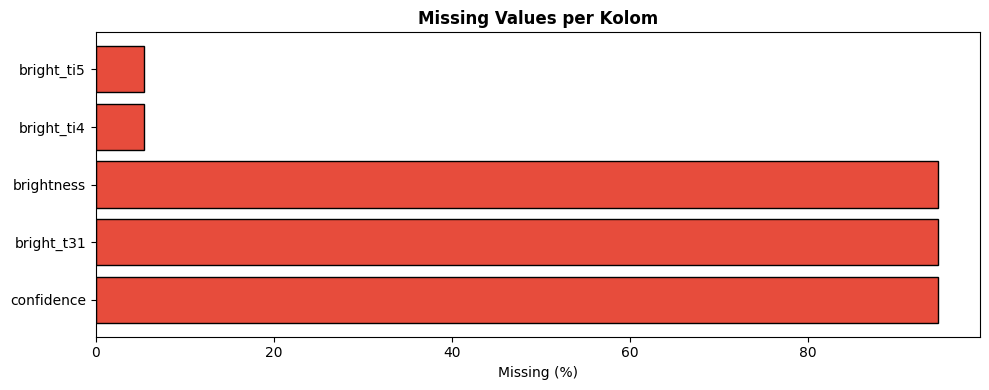

In [12]:
# 4.1 Missing Values
print("=" * 55)
print("4.1 ANALISIS MISSING VALUES")
print("=" * 55)

missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
mv_df = pd.DataFrame({'Jumlah': missing, 'Persen (%)': missing_pct})
mv_df = mv_df[mv_df['Jumlah'] > 0].sort_values('Persen (%)', ascending=False)

if mv_df.empty:
    print("✔️ Tidak ada missing values!")
else:
    print(mv_df)
    # Visualisasi
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(mv_df.index, mv_df['Persen (%)'], color='#E74C3C', edgecolor='black')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Values per Kolom', fontweight='bold')
    plt.tight_layout()
    plt.show()

Menganalisis distribusi nilai **FRP (Fire Radiative Power)** untuk menentukan threshold klasifikasi intensitas kebakaran secara lebih objektif.

In [13]:
# Justifikasi threshold berdasarkan distribusi data
frp_clean = df_raw['frp'].dropna()

print("Distribusi FRP — Statistik Kunci:")
print(f"  Min    : {frp_clean.min():.2f} MW")
print(f"  P25    : {frp_clean.quantile(0.25):.2f} MW")
print(f"  Median : {frp_clean.median():.2f} MW")
print(f"  P75    : {frp_clean.quantile(0.75):.2f} MW")
print(f"  P90    : {frp_clean.quantile(0.90):.2f} MW")
print(f"  P95    : {frp_clean.quantile(0.95):.2f} MW")
print(f"  P99    : {frp_clean.quantile(0.99):.2f} MW")
print(f"  Max    : {frp_clean.max():.2f} MW")

# Proporsi di setiap bin
thresholds = [10, 50, 200]
prev = 0
print("\nProporsi per bin threshold:")
for t in thresholds + [frp_clean.max()]:
    n = ((frp_clean >= prev) & (frp_clean < t)).sum()
    print(f"  [{prev:>6} – {t:>8.0f}) MW : {n:>7,}  ({n/len(frp_clean)*100:.1f}%)")
    prev = t

Distribusi FRP — Statistik Kunci:
  Min    : 0.00 MW
  P25    : 2.56 MW
  Median : 5.13 MW
  P75    : 9.77 MW
  P90    : 19.43 MW
  P95    : 32.34 MW
  P99    : 95.90 MW
  Max    : 6407.11 MW

Proporsi per bin threshold:
  [     0 –       10) MW : 428,189  (75.7%)
  [    10 –       50) MW : 122,245  (21.6%)
  [    50 –      200) MW :  14,023  (2.5%)
  [   200 –     6407) MW :   1,250  (0.2%)


**Justifikasi Threshold Klasifikasi**

Penentuan batas kelas intensitas menggunakan dua pendekatan berbeda
sesuai konteks tiap threshold:

- **FRP < 10 MW (Low):** Merujuk pada batas deteksi minimum sensor MODIS
  (~5–8 MW per piksel), sehingga deteksi di bawah 10 MW berada pada
  ambang sensitivitas instrumen dan merepresentasikan kebakaran dengan
  energi termal sangat rendah *(Sperling, Wooster & Malamud, 2020,
  doi:10.3390/fire3020011)*.

- **FRP 10–50 MW (Moderate):** Berdasarkan distribusi dataset, sebagian besar observasi berada pada rentang ini setelah kelas rendah, yaitu sekitar 21,6% dari total data. Rentang ini merepresentasikan kebakaran dengan intensitas sedang yang masih cukup umum ditemukan.

- **FRP 50–200 MW (High):** Berdasarkan distribusi dataset, nilai FRP di atas 50 MW mulai memasuki ekor distribusi dengan frekuensi yang jauh lebih rendah, yaitu sekitar 2,5% dari total observasi. Hal ini menunjukkan kejadian kebakaran dengan energi termal tinggi relatif lebih jarang terjadi.

- **FRP ≥ 200 MW (Extreme):** Nilai FRP di atas 200 MW hanya mencakup 1.250 observasi atau sekitar 0,2% dari total data, sehingga dapat dikategorikan sebagai kejadian ekstrem (rare events) yang berada pada ekor distribusi. Threshold ini digunakan untuk merepresentasikan hotspot dengan intensitas termal sangat tinggi.

Berdasarkan analisis tersebut, threshold 10, 50, dan 200 MW dipilih karena mampu memisahkan distribusi data menjadi kelompok intensitas yang memiliki makna fisik serta proporsi statistik yang jelas.

## **4.2 Distribusi FRP & Pembuatan Label**

Memvisualisasikan distribusi FRP dan membentuk label kelas intensitas kebakaran berdasarkan threshold yang telah ditentukan.

4.2 DISTRIBUSI FRP & PEMBUATAN LABEL INTENSITAS
Kolom FRP ditemukan: 'frp'
count    565708.000
mean         10.156
std          27.154
min           0.000
25%           2.560
50%           5.130
75%           9.770
max        6407.110
Name: frp, dtype: float64


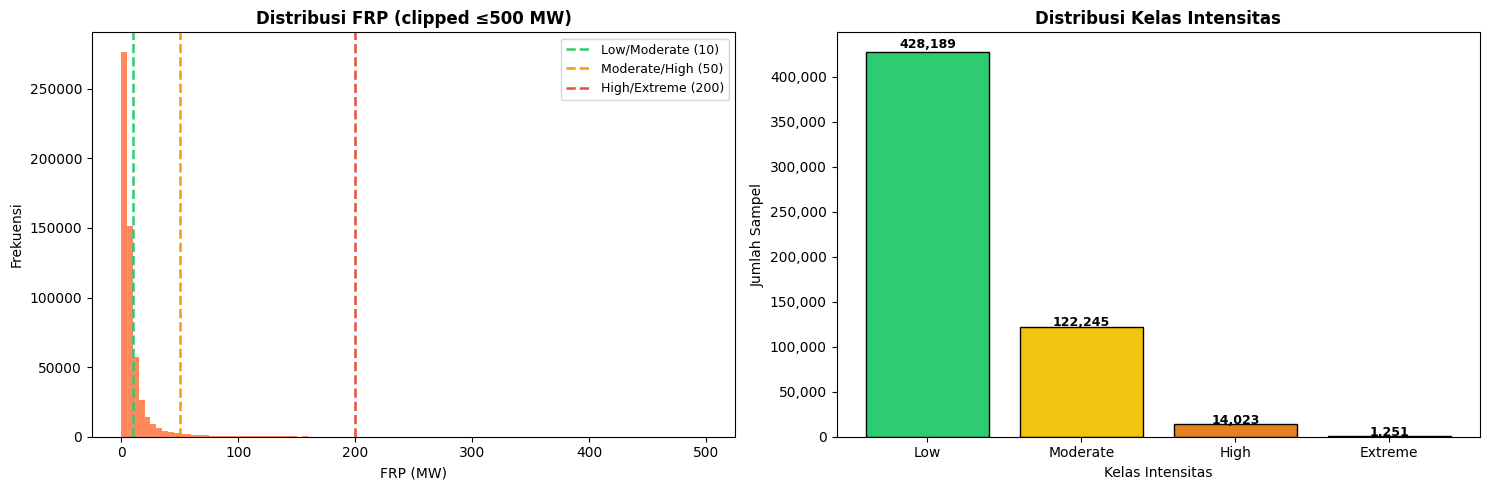


Distribusi Kelas:
  0 (Low       ): 428,189  (75.7%)
  1 (Moderate  ): 122,245  (21.6%)
  2 (High      ):  14,023  (2.5%)
  3 (Extreme   ):   1,251  (0.2%)


In [14]:
# 4.2 Distribusi FRP & Pembuatan Label
print("=" * 55)
print("4.2 DISTRIBUSI FRP & PEMBUATAN LABEL INTENSITAS")
print("=" * 55)

# Identifikasi kolom FRP
frp_col = [c for c in df_raw.columns if c.lower() == 'frp'][0]
print(f"Kolom FRP ditemukan: '{frp_col}'")
print(df_raw[frp_col].describe().round(3))

# Buat label intensitas
def categorize_intensity(frp):
    if pd.isna(frp): return np.nan
    if frp < 10:      return 0  # Low
    if frp < 50:      return 1  # Moderate
    if frp < 200:     return 2  # High
    return 3                     # Extreme

df_raw['intensity_class'] = df_raw[frp_col].apply(categorize_intensity)

# Visualisasi distribusi FRP
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

frp_clipped = df_raw[frp_col].dropna().clip(upper=500)
axes[0].hist(frp_clipped, bins=100, color='#FF6B35', edgecolor='none', alpha=0.8)
for val, lbl, col in zip([10, 50, 200],
                          ['Low/Moderate', 'Moderate/High', 'High/Extreme'],
                          ['#2ECC71', '#F39C12', '#E74C3C']):
    axes[0].axvline(val, color=col, linestyle='--', linewidth=1.8, label=f'{lbl} ({val})')
axes[0].set_title('Distribusi FRP (clipped ≤500 MW)', fontweight='bold')
axes[0].set_xlabel('FRP (MW)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

# Distribusi kelas
class_counts = df_raw['intensity_class'].value_counts().sort_index()
bars = axes[1].bar(
    [LABEL_MAP[i] for i in range(4)],
    [class_counts.get(i, 0) for i in range(4)],
    color=COLORS, edgecolor='black'
)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() * 1.01,
                  f'{int(bar.get_height()):,}',
                  ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Distribusi Kelas Intensitas', fontweight='bold')
axes[1].set_xlabel('Kelas Intensitas')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print("\nDistribusi Kelas:")
for cls, cnt in class_counts.items():
    print(f"  {int(cls)} ({LABEL_MAP[int(cls)]:10s}): {cnt:>7,}  ({cnt/len(df_raw)*100:.1f}%)")

## **4.3. Distribusi Fitur Numerik**

Menganalisis distribusi setiap fitur numerik untuk memahami pola data, sebaran, serta potensi skewness.

4.3 DISTRIBUSI FITUR NUMERIK UTAMA
Fitur numerik tersedia: ['brightness', 'scan', 'track', 'bright_t31', 'confidence']


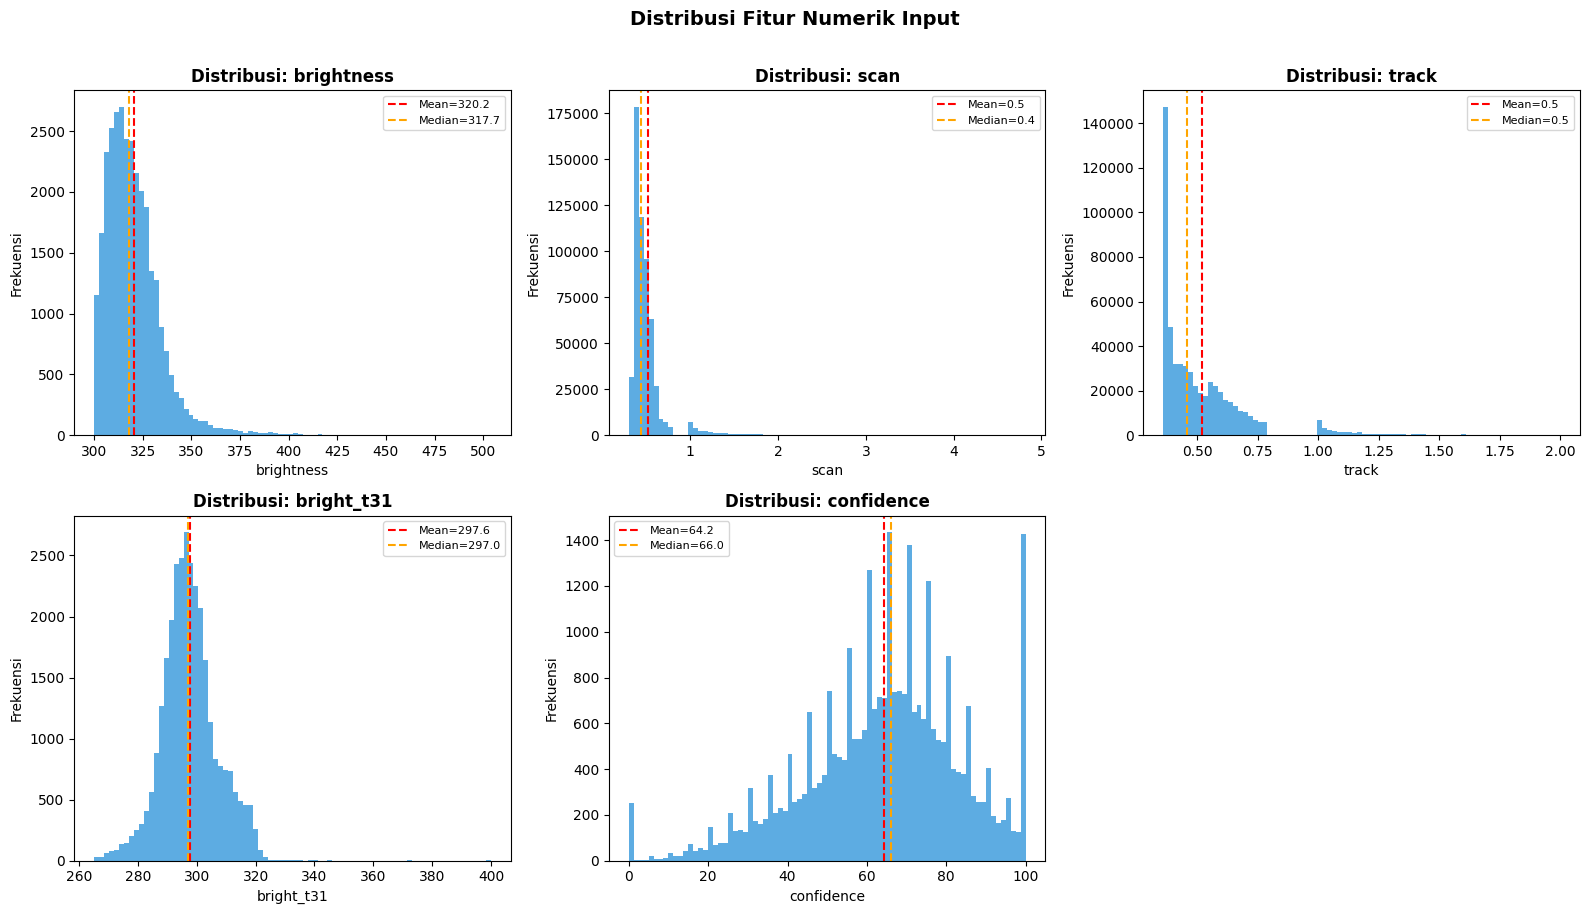

In [15]:
# 4.3 Distribusi Fitur Numerik
print("=" * 55)
print("4.3 DISTRIBUSI FITUR NUMERIK UTAMA")
print("=" * 55)

# Tentukan fitur yang akan dipakai (cek ketersediaan)
CANDIDATE_FEATURES = ['brightness', 'scan', 'track', 'bright_t31', 'confidence']
NUMERIC_FEATURES = [c for c in CANDIDATE_FEATURES if c in df_raw.columns]
print(f"Fitur numerik tersedia: {NUMERIC_FEATURES}")

n = len(NUMERIC_FEATURES)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    data = df_raw[feat].dropna()
    axes[i].hist(data, bins=80, color='#3498DB', edgecolor='none', alpha=0.8)
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.1f}')
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median={data.median():.1f}')
    axes[i].set_title(f'Distribusi: {feat}', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik Input', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **4.4 Analisis Fitur Kategorikal**

Melakukan eksplorasi fitur kategorikal untuk melihat proporsi masing-masing kategori pada dataset.

4.4 FITUR KATEGORIKAL


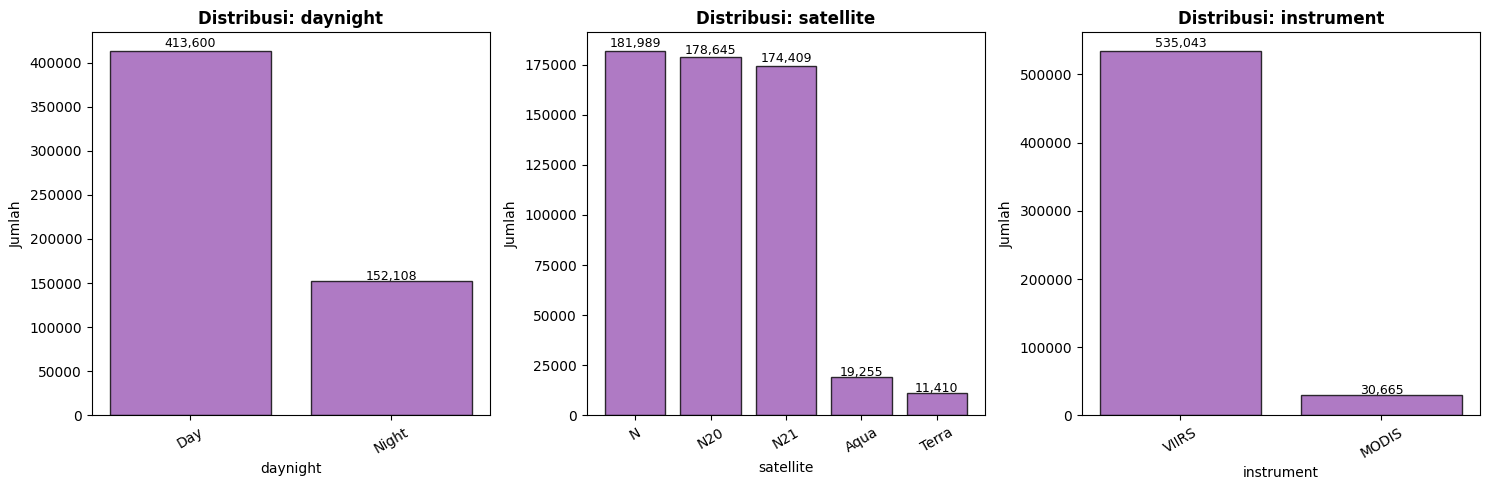


daynight:
daynight
Day      413600
Night    152108
Name: count, dtype: int64

satellite:
satellite
N        181989
N20      178645
N21      174409
Aqua      19255
Terra     11410
Name: count, dtype: int64

instrument:
instrument
VIIRS    535043
MODIS     30665
Name: count, dtype: int64


In [16]:
# 4.4 Analisis Fitur Kategorikal
print("=" * 55)
print("4.4 FITUR KATEGORIKAL")
print("=" * 55)

cat_cols = ['daynight', 'satellite', 'instrument']
cat_cols = [c for c in cat_cols if c in df_raw.columns]

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 5))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    vc = df_raw[col].value_counts()
    ax.bar(vc.index, vc.values, color='#9B59B6', edgecolor='black', alpha=0.8)
    ax.set_title(f'Distribusi: {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    for i, (val, cnt) in enumerate(vc.items()):
        ax.text(i, cnt * 1.01, f'{cnt:,}', ha='center', fontsize=9)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=30)

plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col}:")
    print(df_raw[col].value_counts())

## **4.5 Korelasi Matrix**

Menganalisis korelasi antar fitur numerik untuk mengidentifikasi hubungan linear dan potensi multikolinearitas.

4.5 KORELASI FITUR DENGAN TARGET


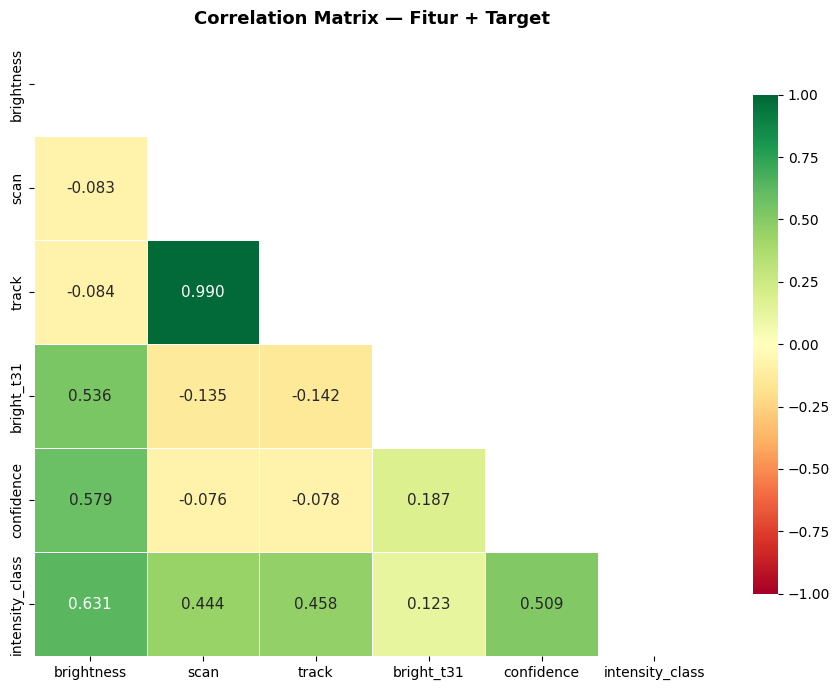


Korelasi terhadap intensity_class (descending):
brightness    0.6312
confidence    0.5091
track         0.4579
scan          0.4440
bright_t31    0.1230
Name: intensity_class, dtype: float64


In [17]:
# 4.5 Korelasi Matrix
print("=" * 55)
print("4.5 KORELASI FITUR DENGAN TARGET")
print("=" * 55)

df_corr = df_raw[NUMERIC_FEATURES + ['intensity_class']].dropna()
corr = df_corr.corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 11})
plt.title('Correlation Matrix — Fitur + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKorelasi terhadap intensity_class (descending):")
print(corr['intensity_class'].drop('intensity_class').sort_values(ascending=False).round(4))

## **4.6 Distribusi Fitur per Kelas**

Menganalisis distribusi setiap fitur numerik terhadap masing-masing kelas intensitas kebakaran—tujuannya mengecek apakah fitur-fitur input memang punya pola yang berbeda antar kelas (Low, Moderate, High, Extreme), sehingga layak dipakai untuk klasifikasi.

4.6 DISTRIBUSI FITUR PER KELAS INTENSITAS


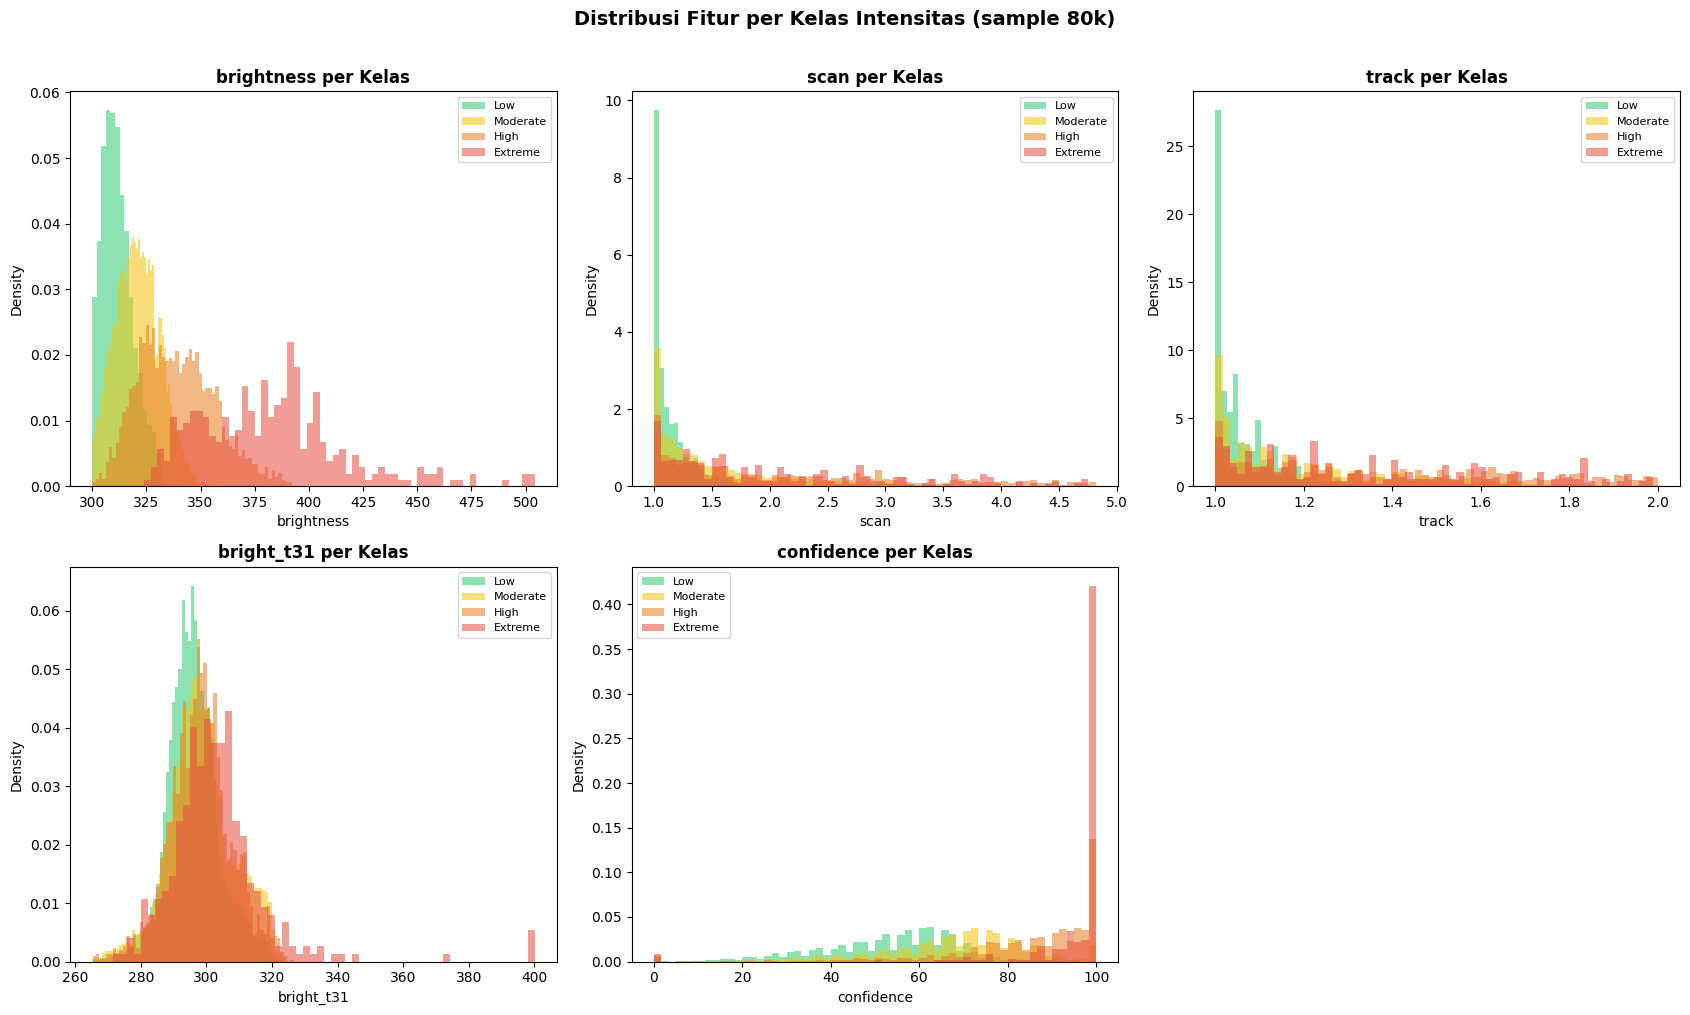

In [18]:
# 4.6 Distribusi Fitur per Kelas
print("=" * 55)
print("4.6 DISTRIBUSI FITUR PER KELAS INTENSITAS")
print("=" * 55)

df_sample = df_corr.sample(min(80_000, len(df_corr)), random_state=SEED)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    for cls in range(4):
        subset = df_sample[df_sample['intensity_class'] == cls][feat]
        axes[i].hist(subset, bins=60, alpha=0.55,
                     label=LABEL_MAP[cls], color=COLORS[cls], density=True)
    axes[i].set_title(f'{feat} per Kelas', fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur per Kelas Intensitas (sample 80k)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **4.7 Boxplot Outlier Analysis**

Menggunakan boxplot untuk mendeteksi keberadaan outlier pada fitur numerik utama.

4.7 ANALISIS OUTLIER (BOXPLOT)


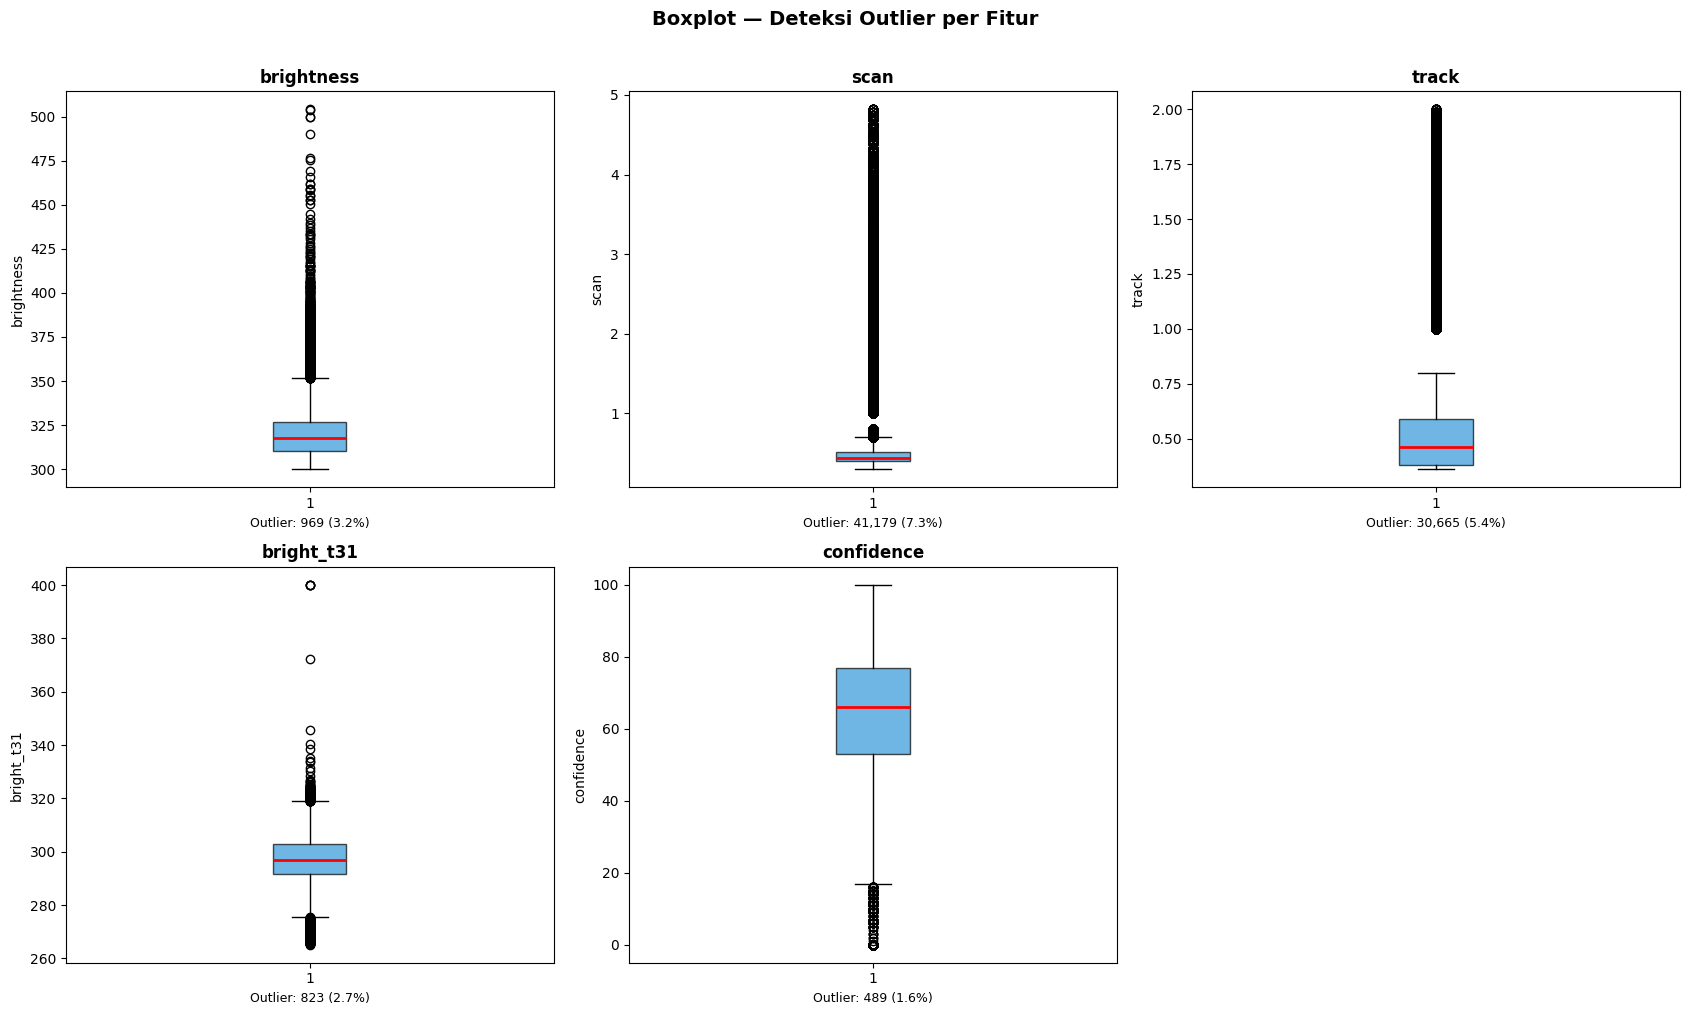

In [19]:
# 4.7 Boxplot Outlier Analysis
print("=" * 55)
print("4.7 ANALISIS OUTLIER (BOXPLOT)")
print("=" * 55)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for i, feat in enumerate(NUMERIC_FEATURES):
    data = df_raw[feat].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
    pct   = n_out / len(data) * 100

    axes[i].boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#3498DB', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_ylabel(feat)
    axes[i].set_xlabel(f'Outlier: {n_out:,} ({pct:.1f}%)', fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplot — Deteksi Outlier per Fitur', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **4.8 Analisis Temporal & Geospasial**

Melakukan analisis temporal dan geospasial untuk memahami pola kebakaran berdasarkan waktu dan lokasi.

4.8 ANALISIS TEMPORAL & SENSOR


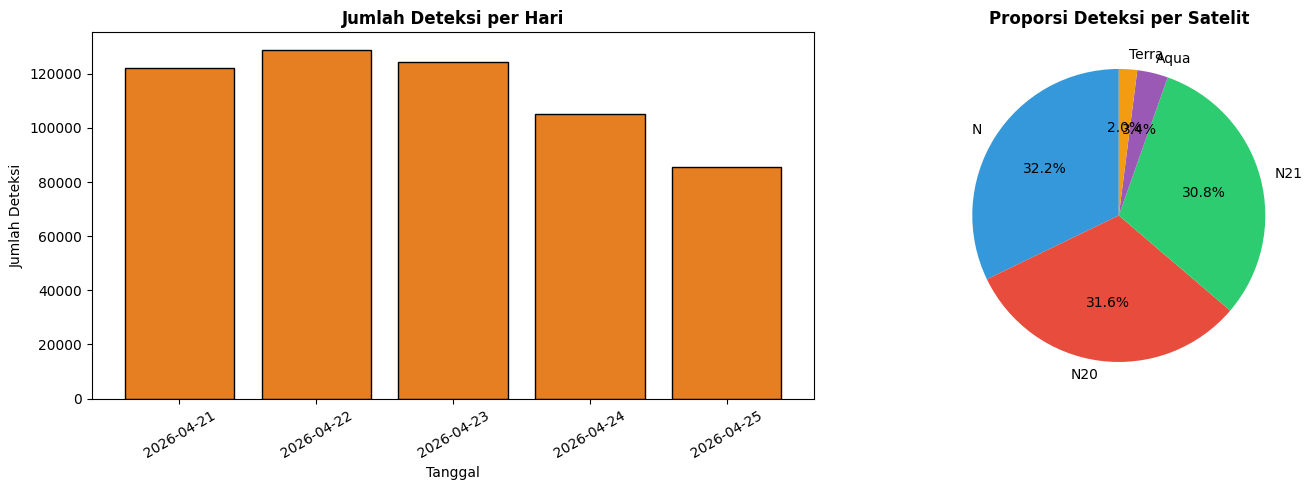

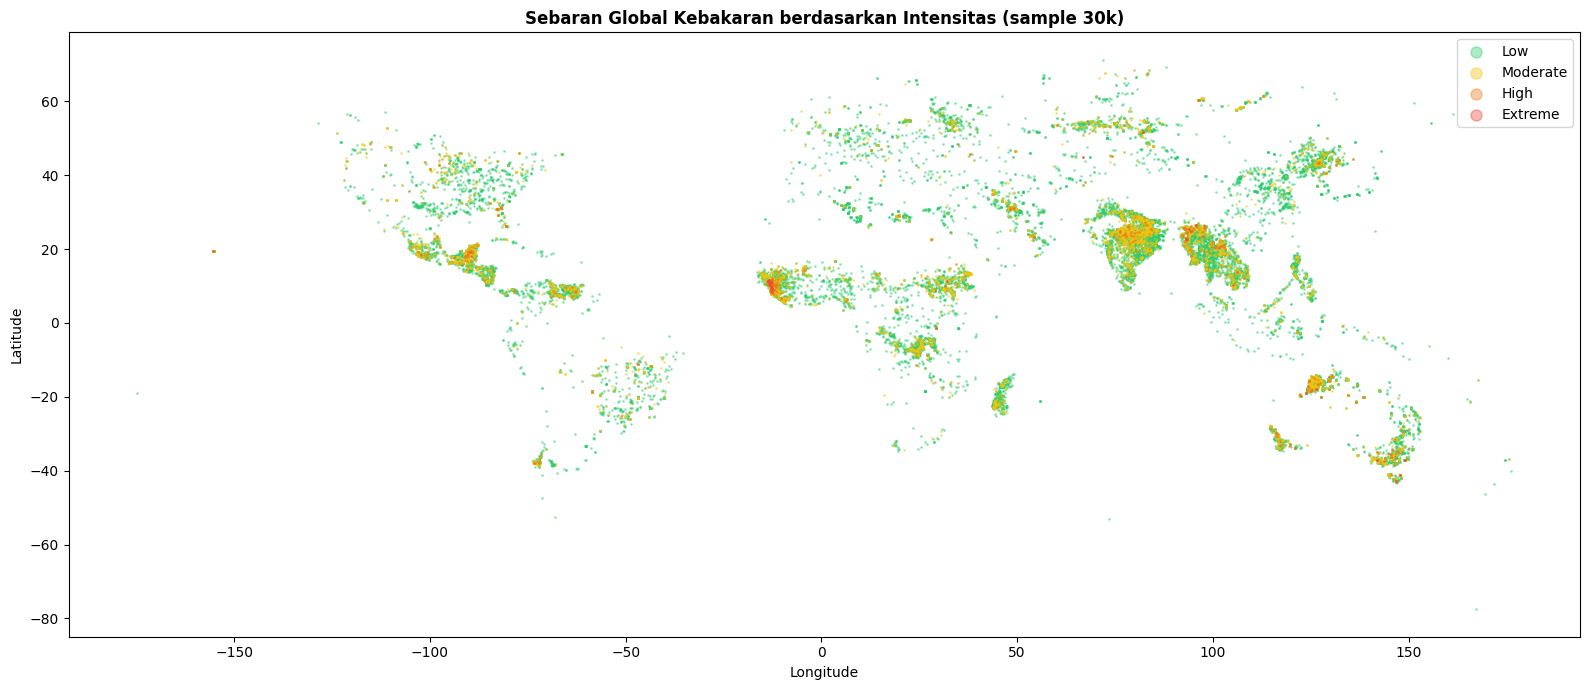

In [20]:
# 4.8 Analisis Temporal & Geospasial
print("=" * 55)
print("4.8 ANALISIS TEMPORAL & SENSOR")
print("=" * 55)

# Distribusi per hari deteksi
if 'acq_date' in df_raw.columns:
    df_raw['acq_date'] = pd.to_datetime(df_raw['acq_date'], errors='coerce')
    daily = df_raw.groupby('acq_date').size().reset_index(name='count')

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].bar(daily['acq_date'].astype(str), daily['count'],
                color='#E67E22', edgecolor='black')
    axes[0].set_title('Jumlah Deteksi per Hari', fontweight='bold')
    axes[0].set_xlabel('Tanggal')
    axes[0].set_ylabel('Jumlah Deteksi')
    axes[0].tick_params(axis='x', rotation=30)

    # Deteksi per sensor
    if 'satellite' in df_raw.columns:
        sat_counts = df_raw['satellite'].value_counts()
        axes[1].pie(sat_counts.values, labels=sat_counts.index,
                    autopct='%1.1f%%', startangle=90,
                    colors=['#3498DB','#E74C3C','#2ECC71','#9B59B6','#F39C12'][:len(sat_counts)])
        axes[1].set_title('Proporsi Deteksi per Satelit', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Kolom 'acq_date' tidak tersedia — skip temporal analysis.")

# Scatter plot geospasial
if 'latitude' in df_raw.columns and 'longitude' in df_raw.columns:
    sample_geo = df_raw.dropna(subset=['latitude','longitude','intensity_class']).sample(30_000, random_state=SEED)
    plt.figure(figsize=(16, 7))
    for cls in range(4):
        sub = sample_geo[sample_geo['intensity_class'] == cls]
        plt.scatter(sub['longitude'], sub['latitude'],
                    s=1, alpha=0.4, color=COLORS[cls], label=LABEL_MAP[cls])
    plt.title('Sebaran Global Kebakaran berdasarkan Intensitas (sample 30k)', fontweight='bold')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend(markerscale=8, fontsize=10)
    plt.tight_layout()
    plt.show()

FRP → digunakan untuk membuat intensity_class (label) → hapus dari fitur input
brightness, scan, track, bright_t31, confidence → inilah yang sensor tangkap
                                                  tanpa harus tahu FRP

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Tahapan preprocessing agar data siap dilatih model deep learning:

1. **Seleksi Fitur** — Pilih fitur input yang relevan secara domain
2. **Handle Missing Values** — Drop/isi dengan median per kelas  
3. **Encoding Fitur Kategorikal** — `daynight` (D=1, N=0)
4. **Outlier Capping** — IQR ×3.0 (untuk data fisik satelit yang heavy-tailed)
5. **Train / Validation / Test Split** — 64% / 16% / 20% dengan stratifikasi
6. **Standarisasi** — StandardScaler fit pada train saja
7. **Simpan Artefak** — CSV + scaler.pkl + feature_cols.pkl

## **5.1 Feature Selection & Encoding**

Melakukan seleksi fitur, pemisahan fitur-target, serta encoding pada fitur kategorikal agar dapat diproses oleh model machine learning.

In [21]:
# 5.1 Feature Selection & Encoding
print("=" * 55)
print("5.1 FEATURE SELECTION")
print("=" * 55)

# Encode daynight
if "daynight" in df_raw.columns:
    df_raw["daynight_enc"] = df_raw["daynight"].map({"D": 1,"N": 0})
    print("daynight encoded")

# Encode instrument
if "instrument" in df_raw.columns:
    instrument_dummies = pd.get_dummies(df_raw["instrument"], prefix="instrument", dtype=int)
    df_raw = pd.concat([df_raw,instrument_dummies], axis=1)
    print("instrument encoded")

# Final features
FEATURE_COLS = [
    "brightness",
    "scan",
    "track",
    "bright_t31",
    "confidence",
    "daynight_enc"
]

# Tambahkan kolom instrument
instrument_cols = [col for col in df_raw.columns if col.startswith("instrument_")]

FEATURE_COLS += instrument_cols
TARGET_COL = "intensity_class"

print("\nFeature columns:")
print(FEATURE_COLS)

# Working dataframe
df_model = df_raw[FEATURE_COLS + [TARGET_COL]].copy()
print(f"\nShape awal: "f"{df_model.shape}")

5.1 FEATURE SELECTION
daynight encoded
instrument encoded

Feature columns:
['brightness', 'scan', 'track', 'bright_t31', 'confidence', 'daynight_enc', 'instrument_MODIS', 'instrument_VIIRS']

Shape awal: (565708, 9)


## **5.2 Handle Missing Values**

Menangani missing values menggunakan strategi imputasi yang sesuai berdasarkan karakteristik masing-masing fitur.

In [22]:
# 5.2 Handle Missing Values
print("=" * 55)
print("5.2 HANDLE MISSING VALUES")
print("=" * 55)

print("Sebelum:")
print(df_model.isnull().sum())

# Drop baris tanpa target
df_model = df_model.dropna(subset=[TARGET_COL])
df_model[TARGET_COL] = df_model[TARGET_COL].astype(int)

# Global median imputation
for feat in FEATURE_COLS:
    n_miss = df_model[feat].isnull().sum()
    if n_miss > 0:
        median_val = df_model[feat].median()
        df_model[feat] = df_model[feat].fillna(median_val)
        print(f"  {feat}: {n_miss:,} missing → diisi median global ({median_val:.4f})")

print("\nSetelah:")
print(df_model.isnull().sum())
print(f"\nShape setelah handle missing: {df_model.shape}")

5.2 HANDLE MISSING VALUES
Sebelum:
brightness          535043
scan                     0
track                    0
bright_t31          535043
confidence          535043
daynight_enc        565708
instrument_MODIS         0
instrument_VIIRS         0
intensity_class          0
dtype: int64
  brightness: 535,043 missing → diisi median global (317.7100)
  bright_t31: 535,043 missing → diisi median global (296.9700)
  confidence: 535,043 missing → diisi median global (66.0000)
  daynight_enc: 565,708 missing → diisi median global (nan)

Setelah:
brightness               0
scan                     0
track                    0
bright_t31               0
confidence               0
daynight_enc        565708
instrument_MODIS         0
instrument_VIIRS         0
intensity_class          0
dtype: int64

Shape setelah handle missing: (565708, 9)


## **5.3 Outlier Capping IQR**

Melakukan penanganan outlier menggunakan metode **Interquartile Range (IQR)** agar distribusi data lebih stabil.

In [23]:
# 5.3 Outlier Capping IQR
print("=" * 55)
print("5.3 OUTLIER CAPPING (IQR × 3.0)")
print("=" * 55)

# Hanya numerik kontinyu (bukan encoded binary)
cap_cols = [c for c in FEATURE_COLS if c != 'daynight_enc']
bounds = {}

for col in cap_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3.0 * IQR
    upper = Q3 + 3.0 * IQR
    n_cap = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    pct   = n_cap / len(df_model) * 100
    df_model[col] = df_model[col].clip(lower=lower, upper=upper)
    bounds[col] = (lower, upper)
    print(f"  {col:15s}: [{lower:.2f}, {upper:.2f}] → {n_cap:,} ({pct:.2f}%) di-cap")

print(f"\nShape setelah capping: {df_model.shape}")

5.3 OUTLIER CAPPING (IQR × 3.0)
  brightness     : [317.71, 317.71] → 30,661 (5.42%) di-cap
  scan           : [0.04, 0.88] → 30,665 (5.42%) di-cap
  track          : [-0.25, 1.22] → 8,650 (1.53%) di-cap
  bright_t31     : [296.97, 296.97] → 30,632 (5.41%) di-cap
  confidence     : [66.00, 66.00] → 29,946 (5.29%) di-cap
  instrument_MODIS: [0.00, 0.00] → 30,665 (5.42%) di-cap
  instrument_VIIRS: [1.00, 1.00] → 30,665 (5.42%) di-cap

Shape setelah capping: (565708, 9)


## **5.4 Train / Val / Test Split**

Membagi dataset menjadi data training, validation, dan testing untuk proses pelatihan serta evaluasi model.

In [24]:
# 5.4 Train / Val / Test Split
print("=" * 55)
print("5.4 TRAIN / VALIDATION / TEST SPLIT")
print("=" * 55)

X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

# 80% train-val, 20% test
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Dari 80%, ambil 20% untuk validasi → efektif 64/16/20
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.20, random_state=SEED, stratify=y_tv)

print(f"Train      : {X_train.shape}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation : {X_val.shape}   ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test       : {X_test.shape}   ({len(X_test)/len(X)*100:.1f}%)")

print("\nDistribusi kelas — Train:")
for cls in range(4):
    n = (y_train == cls).sum()
    print(f"  {LABEL_MAP[cls]:10s}: {n:>7,}  ({n/len(y_train)*100:.1f}%)")

5.4 TRAIN / VALIDATION / TEST SPLIT
Train      : (362052, 8)  (64.0%)
Validation : (90514, 8)   (16.0%)
Test       : (113142, 8)   (20.0%)

Distribusi kelas — Train:
  Low       : 274,040  (75.7%)
  Moderate  :  78,237  (21.6%)
  High      :   8,974  (2.5%)
  Extreme   :     801  (0.2%)


In [25]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    print(f"{LABEL_MAP[cls]:10s}: {weight:.2f}")

Class weights:
Low       : 0.33
Moderate  : 1.16
High      : 10.09
Extreme   : 113.00


## **5.5 Standarisasi**

Melakukan standarisasi fitur numerik agar seluruh fitur berada pada skala yang seragam.

In [26]:
# 5.5 Standarisasi
print("=" * 55)
print("5.5 STANDARISASI (StandardScaler)")
print("=" * 55)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("Statistik X_train setelah scaling:")
print(f"  Mean : {X_train_sc.mean(axis=0).round(4)}")
print(f"  Std  : {X_train_sc.std(axis=0).round(4)}")
print("\n✔️ Scaler fit hanya pada data train — tidak ada data leakage.")

5.5 STANDARISASI (StandardScaler)
Statistik X_train setelah scaling:
  Mean : [ 0. -0.  0.  0.  0. nan  0.  0.]
  Std  : [ 0.  1.  1.  0.  0. nan  0.  0.]

✔️ Scaler fit hanya pada data train — tidak ada data leakage.


## **5.6 Simpan Data Preprocessed**

In [27]:
# 5.6 Simpan Data Preprocessed
print("=" * 55)
print("5.6 SIMPAN DATA PREPROCESSED")
print("=" * 55)

OUT_DIR = '/content/wildfire_preprocessing'
os.makedirs(OUT_DIR, exist_ok=True)

# Simpan CSV split
for split, X_sc, y_split in [('train', X_train_sc, y_train),
                               ('val',   X_val_sc,   y_val),
                               ('test',  X_test_sc,  y_test)]:
    out_df = pd.DataFrame(X_sc, columns=FEATURE_COLS)
    out_df[TARGET_COL] = y_split
    out_df.to_csv(f'{OUT_DIR}/{split}.csv', index=False)
    print(f"  ✔️ {split}.csv  → {out_df.shape}")

# Simpan artefak preprocessing
joblib.dump(scaler,       f'{OUT_DIR}/scaler.pkl')
joblib.dump(FEATURE_COLS, f'{OUT_DIR}/feature_cols.pkl')
joblib.dump(bounds,       f'{OUT_DIR}/outlier_bounds.pkl')
print("  ✔️ scaler.pkl")
print("  ✔️ feature_cols.pkl")
print("  ✔️ outlier_bounds.pkl")

print("\n📁 Isi folder output:")
for f in sorted(os.listdir(OUT_DIR)):
    size = os.path.getsize(f'{OUT_DIR}/{f}') / 1e6
    print(f"  {f}  ({size:.2f} MB)")

5.6 SIMPAN DATA PREPROCESSED
  ✔️ train.csv  → (362052, 9)
  ✔️ val.csv  → (90514, 9)
  ✔️ test.csv  → (113142, 9)
  ✔️ scaler.pkl
  ✔️ feature_cols.pkl
  ✔️ outlier_bounds.pkl

📁 Isi folder output:
  feature_cols.pkl  (0.00 MB)
  outlier_bounds.pkl  (0.00 MB)
  scaler.pkl  (0.00 MB)
  test.csv  (11.16 MB)
  train.csv  (35.71 MB)
  val.csv  (8.93 MB)


## **5.7 Download Hasil Preprocessing**

In [28]:
# 5.7 Download Hasil Preprocessing
import zipfile
from google.colab import files

ZIP_PATH = '/content/wildfire_preprocessing.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(OUT_DIR):
        zf.write(f'{OUT_DIR}/{fname}', fname)

print(f"Ukuran zip: {os.path.getsize(ZIP_PATH)/1e6:.1f} MB")
files.download(ZIP_PATH)
print("✔️ Download dimulai — cek folder Downloads kamu.")

Ukuran zip: 2.1 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔️ Download dimulai — cek folder Downloads kamu.
